🌟 Exercise 1 : Defining the Problem and Data Collection for Loan Default Prediction


---

**1. Problem Statement**

The goal is to **predict the probability of loan default** using machine learning algorithms. Accurately identifying potential defaults will help financial institutions minimize losses, improve credit risk management, and make data-driven lending decisions.

**2. Types of Data Needed**

To build an effective predictive model, you would typically need the following data about each applicant:
* Personal Details:
	* Gender
	* Marital Status
* Financial Information:
	* Applicant’s Income
	*	Co-applicant’s Income
	*	Employment Status
	*	Credit Score
* Loan Details:
	*	Loan Amount
	*	Loan Term (Loan_Amount_Term)
* Repayment and Credit History:
	*	History of past loan repayments
	*	Number of previous defaults or delays
* Target Variable:
	*	Loan Status (Defaulted or Not)

**3. Data Sources**

Data for this project can be collected from:
* Internal records of financial institutions
* Credit bureaus


  ---

🌟 Exercise 2 : Feature Selection and Model Choice for Loan Default Prediction

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/loan.csv')
display(df)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
# Переводим бинарные категориальные в 0 и 1
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Для переменных с тремя категориями — one-hot encoding:
df = pd.get_dummies(df, columns=['Property_Area'])

# Теперь все признаки числовые и готовы для анализа!

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,1,False,False,True
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0.0,0.0,0,1,0.0,2900,0.0,71.0,360.0,1.0,1,True,False,False
610,LP002979,1.0,1.0,3+,1,0.0,4106,0.0,40.0,180.0,1.0,1,True,False,False
611,LP002983,1.0,1.0,1,1,0.0,8072,240.0,253.0,360.0,1.0,1,False,False,True
612,LP002984,1.0,1.0,2,1,0.0,7583,0.0,187.0,360.0,1.0,1,False,False,True


In [ ]:
df['Credit_History'].isnull().sum() / df.shape[0] * 100

np.float64(8.143322475570033)

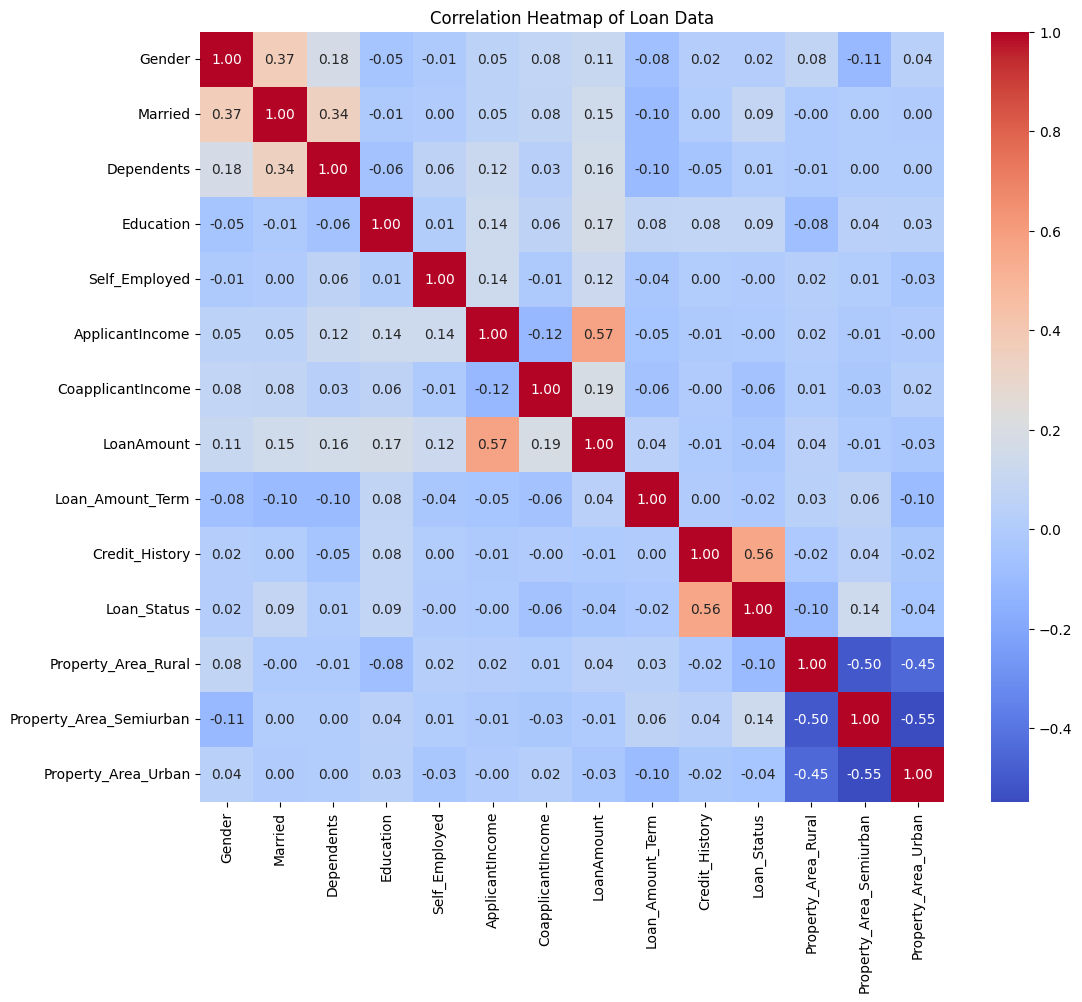

In [ ]:
# prompt: create a heatmap for most strong  relationship

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for handling NaN

# Handle the 'Dependents' column: replace '3+' with '3' and convert to numeric
# You might also want to handle potential NaN values, for instance, by filling them
# with a suitable value like the mode or 0.
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)
# You might also consider filling NaN values if they exist:
# df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0]) # Example: fill with mode

# Compute the correlation matrix
# Exclude non-numeric columns explicitly if there are others you haven't converted
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Loan Data')
plt.show()

---

**Credit history is a key factor!**

• All other characteristics (income, loan amount, term, region, gender, etc.) correlate very weakly with loan approval.

* 1. Loan_Status (target feature)
  *  Credit_History and Loan_Status: 0.56 — The strongest positive correlation!
→ This means that “credit history” (1 = good, 0 = bad/no) has a very strong influence on the probability of loan approval.

* 2. Internal relationships between features:
  *  ApplicantIncome and LoanAmount: 0.57
→ The higher the applicant’s income, the larger the loan he/she receives. This is logical.
  *  Credit_History and LoanAmount_Term: 0.56
→ People with a good history are more likely to receive loans for a longer term.



---

🌟 Exercise 3 : Training, Evaluating, and Optimizing the Model



## Model Evaluation Approach

For the Loan Prediction task, I chose the **Random Forest** algorithm due to its robustness and ability to handle both numerical and categorical features effectively.

The evaluation process follows these steps:

1. **Data Splitting:**  
   The dataset will be split into training and test sets (70% for training, 30% for testing) to ensure reliable evaluation on unseen data.

2. **Model Training:**  
   The Random Forest model is trained on the training set.

3. **Prediction:**  
   Predictions are made on the test set to evaluate model performance.

4. **Performance Metrics:**  
   The model will be assessed using several key metrics:
   - **Accuracy** – Overall percentage of correct predictions.
   - **Precision** – Proportion of correctly predicted approvals out of all approvals predicted.
   - **Recall** – Proportion of actual approvals correctly identified by the model.
   - **F1-score** – Harmonic mean of Precision and Recall, balancing false positives and false negatives.
   - **ROC-AUC** – Measures the model’s ability to distinguish between approved and rejected loans.
   - **Confusion Matrix** – Shows the breakdown of true/false positives and negatives.

This evaluation framework provides a comprehensive understanding of the model’s strengths and weaknesses, helping ensure it reliably predicts loan approvals while minimizing errors.

---

🌟 Exercise 4 : Designing Machine Learning Solutions for Specific Problems
Instructions

**Predicting Stock Prices : predict future prices**

* Decision Tree

Decision trees are versatile machine learning algorithms used for both classification and regression tasks. They provide a graphical representation of possible solutions to a decision based on certain conditions.

**Organizing a Library of Books : group books into genres or categories based on similarities.**
* k-Nearest Neighbors (k-NN)


The k-Nearest Neighbors algorithm, or k-NN, is a simple and effective supervised machine learning algorithm used for classification and regression tasks. It is a type of instance-based learning, where the model is not explicitly trained on a dataset, but instead, it memorizes the dataset during the training phase.



**Program a robot to navigate and find the shortest path in a maze.**

* A*

A* is a pathfinding algorithm used to find the shortest route between two points. It is widely used in games, robotics, and navigation.

In [ ]:
🌟 Exercise 5 : Designing an Evaluation Strategy for Different ML Models
Instructions

---


**Supervised Learning**
* Algorithms Used — Random Forest
	*	**Accuracy:** Overall proportion of correct predictions.
	*	**Precision:** Fraction of predicted positives that are actually positive.
	*	**Recall:** Fraction of actual positives correctly identified.
	*	**F1-Score:** Balance between precision and recall.
	*	**ROC-AUC:** Measures how well the model separates the classes.
	*	**Confusion Matrix:** Shows true/false positives/negatives.

  ---



---


**Unsupervised Learning**
* Algorithms Used — K-means Clustering

For evaluating unsupervised models (clustering), metrics such as silhouette score, the elbow method, and cluster validity indices (e.g., Davies-Bouldin, Calinski-Harabasz) are commonly used. These measures help determine the optimal number of clusters and assess the quality of the clustering without relying on ground truth labels.


---

---

**Reinforcement Learning**
* Algorithms Used — Q-Learning, SARSA, DQN, DDPG.


To measure the success of a reinforcement learning model, I would track cumulative reward (the total reward earned over time), check for convergence (whether the learning process stabilizes to a consistent policy), and monitor the balance between exploration (trying new actions) and exploitation (using known good actions). A successful RL model should achieve high cumulative reward, demonstrate stable learning, and maintain an effective balance between exploring new strategies and exploiting learned ones.

---